In [2]:
'''libraries'''
#Data
import pandas as pd

#Plots
import matplotlib.pyplot as plt

#fits
#from scipy.optimize import curve_fit

#math
import numpy as np
import scipy.integrate as integrate


#Constants
from scipy.constants import physical_constants
m_u=physical_constants['atomic mass constant energy equivalent in MeV'][0]
from scipy.constants import speed_of_light as c

#Usefull
from tqdm.notebook import tqdm
import os
from scipy.interpolate import interp1d
import pynucastro as pyna
#%matplotlib widget

In [3]:
initial_time=1 #seconds
final_time=4.32E7 #seconds 500 days= 4.32E7 seconds 100 days= 8.64E7 seconds
N_steps=100000
#time = np.exp(np.linspace(np.log(initial_time), np.log(final_time), N_steps))

def dudt_funtion_of_E_t(ta, u, b, tc, E__, time):
    # ensure numpy arrays
    time = np.asarray(time)
    E__  = np.asarray(E__)

    x = ta * tc
    idx = np.searchsorted(time, x, side="left")

    # clamp to valid range [0, len(E__)-1]
    if idx <= 0:
        E_val = E__[0]
    elif idx >= len(E__):
        E_val = E__[-1]
    else:
        E_val = E__[idx]

    if ta <= 1:
        return (E_val)/(ta**3) - u*((4/ta) + 3*ta/(4*b))
    else:
        return (E_val)/(ta**3) - u*((4/ta) + 3*ta/(4*b))#(E_val)/(ta**3) - (u/ta)*(4 + 3/(4*b))


def solucionar(U_0,tau_n,b,tc,n,E__,time):
    U_n=np.zeros(n)
    U_n[0]=U_0
    
    h=tau_n[1]-tau_n[0]
    for i in range(len(U_n)):
    
        k1=h*dudt_funtion_of_E_t(tau_n[i],U_n[i],b,tc,E__,time)
        k2=h*dudt_funtion_of_E_t(tau_n[i]+h/2,U_n[i]+k1/2,b,tc,E__,time)
        k3=h*dudt_funtion_of_E_t(tau_n[i]+h/2,U_n[i]+k2/2,b,tc,E__,time)
        k4=h*dudt_funtion_of_E_t(tau_n[i]+h,U_n[i]+k3,b,tc,E__,time)
        if i!=len(U_n)-1:
            U_n[i+1]=U_n[i]+(1/6)*(k1+2*k2+2*k3+k4)
    return U_n

def termalizacion(time,Mey,Vey,E):
    #Important Values
    
    #time

    #termalizations
    tb=12.9*((Mey/0.01)**(2/3))*((Vey/0.2)**(-2))*24*60*60 #termalization beta particles
    ty=0.3*np.sqrt(Mey/0.01)*(0.2/Vey)*24*60*60 ##termalization gamma particles
    f_gamma=1-np.exp(-(ty/time)**2)
    f_electrons=(1+time/tb)**(-1)
    f_beta=0.2*f_electrons+0.5*f_gamma
    return E*f_beta

def generar_graficas(M,k,b,U_0,tau_0,tau_f,n,E_,time):
    E_=termalizacion(time,M,b,E_)
    M=M*(1.989*10**30)#kg
    tc=np.sqrt(3*k*M/(4*np.pi*(b*c)**2))
    
    Tau_n=np.linspace(tau_0,tau_f,n)
    Uo=solucionar(U_0,Tau_n,b,tc,n,E_,time)
    te=tc*Tau_n
    tedias=te*(1/(60*60*24))
    U=((3*M)/(4*np.pi*((b*c)**3)*((tc)**(2))))*Uo
    L=np.zeros(len(U))
    #i_tc=np.searchsorted(te,tc)
    #L[:i_tc]=((np.pi*((b*c)**2)*c)*(te[:i_tc]**4)/(tc**2))*U[:i_tc]*10**7
    L=((np.pi*((b*c)**2)*c)*(te**4)/(tc**2))*U*10**7
    #calpha=L[i_tc-1]/E_[np.searchsorted(time,tc)]
    #print(calpha,L[i_tc-1],E_[np.searchsorted(t,tc)])    
    #L[i_tc:]=((np.pi*c*(b*c)**2))*(te[i_tc:]**2)*U[i_tc:]*10**7
    
    #spline_interp = interp1d(time, E_, kind='linear', fill_value="extrapolate")
    #e_new=spline_interp(te)
    #L[i_tc:]=calpha*e_new[i_tc:]
    #T=(calpha,L[i_tc],E_[np.searchsorted(time,tc)])  
    T=0#(c*U/(Sb*4))**(1/4)
    
    
    return [U,L,T,tedias]

In [4]:
df_1 = pd.read_csv("Runs/Run_1/toplist.dat",sep="\s{2,}",skiprows=2,header=None, engine='python')
df_3=pd.read_csv("Runs/Run_3/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
df_9=pd.read_csv("Runs/Run_tian_NHMF_9/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
df_11=pd.read_csv("Runs/Run_zhou_NMHF_11/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
df_13=pd.read_csv("Runs/Run_zhou_SONG_13/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
df_14=pd.read_csv("Runs/Run_tian_SONG_3_14/toplist.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')


In [5]:
L_1=generar_graficas(0.05,0.02,0.2,10**10,0.001,85,100000,0.8*df_1[1]*1e-4,df_1[0])
L_2=generar_graficas(0.05,0.02,0.2,10**10,0.001,85,100000,0.8*df_3[1]*1e-4,df_3[0])
L_3=generar_graficas(0.05,0.02,0.2,10**10,0.001,85,100000,0.8*df_9[1]*1e-4,df_9[0])
L_4=generar_graficas(0.05,0.02,0.2,10**10,0.001,85,100000,0.8*df_11[1]*1e-4,df_11[0])
L_5=generar_graficas(0.05,0.02,0.2,10**10,0.001,85,100000,0.8*df_13[1]*1e-4,df_13[0])
L_6=generar_graficas(0.05,0.02,0.2,10**10,0.001,85,100000,0.8*df_14[1]*1e-4,df_14[0])
L_AT2017gfo= pd.read_csv("observations/AT2017gfo.csv",sep=';',skiprows=0,header=None, engine= 'python')
L_AT2017gfo[1] = L_AT2017gfo[1].str.replace(",", ".", regex=False).astype(float)
L_AT2017gfo[0] = L_AT2017gfo[0].str.replace(",", ".", regex=False).astype(float)
L_error_AT2017gfo= pd.read_csv("observations/AT2017_E.csv",sep=';',skiprows=0,header=None, engine= 'python')
L_error_AT2017gfo[0] = L_error_AT2017gfo[0].str.replace(",", ".", regex=False).astype(float)
L_error_AT2017gfo[1] = L_error_AT2017gfo[1].str.replace(",", ".", regex=False).astype(float)
L_error_AT2017gfo[2] = L_error_AT2017gfo[2].str.replace(",", ".", regex=False).astype(float)
L_error_AT2017gfo[3] = L_error_AT2017gfo[3].str.replace(",", ".", regex=False).astype(float)
ye=10**(L_error_AT2017gfo[1])*(L_error_AT2017gfo[2]-L_error_AT2017gfo[3])/(0.5*np.log(10))
L_AT2023vfi= pd.read_csv("observations/AT2023vfi.csv",sep=';',skiprows=0,header=None, engine= 'python')
L_AT2023vfi[1] = L_AT2023vfi[1].str.replace(",", ".", regex=False).astype(float)
L_AT2023vfi[0] = L_AT2023vfi[0].str.replace(",", ".", regex=False).astype(float)
L_error_AT2023vfi= pd.read_csv("observations/AT2023vfi_E.csv",sep=';',skiprows=0,header=None, engine= 'python')
L_error_AT2023vfi[0] = L_error_AT2023vfi[0].str.replace(",", ".", regex=False).astype(float)
L_error_AT2023vfi[1] = L_error_AT2023vfi[1].str.replace(",", ".", regex=False).astype(float)
L_error_AT2023vfi[2] = L_error_AT2023vfi[2].str.replace(",", ".", regex=False).astype(float)
L_error_AT2023vfi[3] = L_error_AT2023vfi[3].str.replace(",", ".", regex=False).astype(float)
ye2=10**(L_error_AT2023vfi[1])*(L_error_AT2023vfi[2]-L_error_AT2023vfi[3])/(0.5*np.log(10))

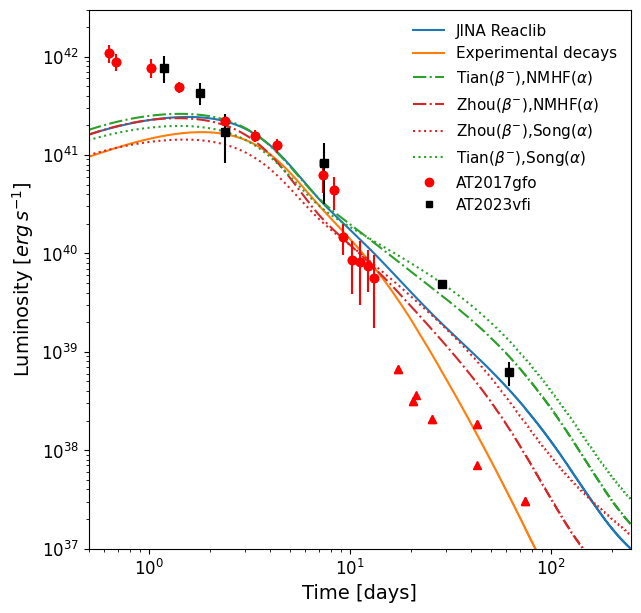

In [8]:
plt.figure(figsize=(7,7))
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})
plt.plot(L_1[3],L_1[1],label="JINA Reaclib")
plt.plot(L_2[3],L_2[1],label="Experimental decays")
plt.plot(L_3[3],L_3[1],label=r"Tian($\beta^{-}$),NMHF($\alpha$)",linestyle='-.')
plt.plot(L_4[3],L_4[1],label=r"Zhou($\beta^{-}$),NMHF($\alpha$)",linestyle='-.')
plt.plot(L_5[3],L_5[1],label=r"Zhou($\beta^{-}$),Song($\alpha$)",linestyle=':',color='C3')
plt.plot(L_6[3],L_6[1],label=r"Tian($\beta^{-}$),Song($\alpha$)",linestyle=':',color='C2')
plt.plot(L_error_AT2017gfo[0],10**(L_error_AT2017gfo[1]), 'o', label='AT2017gfo', color='red')
plt.errorbar(L_error_AT2017gfo[0],10**(L_error_AT2017gfo[1]), yerr=ye, fmt='o', color='red')
plt.plot(L_AT2017gfo[0][20:],10**(L_AT2017gfo[1][20:]), '^', color='red')
plt.plot(L_AT2023vfi[0],10**(L_AT2023vfi[1]), 's', label='AT2023vfi', markersize=4,color='black')
plt.errorbar(L_error_AT2023vfi[0],10**(L_error_AT2023vfi[1]), yerr=ye2, fmt='s', color='black')
plt.xlabel("Time [days]")
plt.ylabel(r"Luminosity $[erg\,s^{-1}]$")
plt.yscale("log")
plt.xscale("log")
plt.ylim(1e37,3e42)
plt.xlim(0.5,250)
plt.legend(loc="upper right", ncol=1,frameon=False,fontsize=11)
plt.savefig("Luminosity_all_models.png",dpi=1200)